# <div style="direction:rtl;text-align:right;font-family:B Lotus, B Nazanin, Tahoma">رویدادهای ماوس در OpenCV</div>

<div style="direction:rtl;text-align:right;font-family:Tahoma">
در ابتدا تمام event یا رویدادهای موجود را چاپ میکنیم:</div>

In [1]:
import cv2
events = [i for i in dir(cv2) if 'EVENT' in i]
print( events )


['EVENT_FLAG_ALTKEY', 'EVENT_FLAG_CTRLKEY', 'EVENT_FLAG_LBUTTON', 'EVENT_FLAG_MBUTTON', 'EVENT_FLAG_RBUTTON', 'EVENT_FLAG_SHIFTKEY', 'EVENT_LBUTTONDBLCLK', 'EVENT_LBUTTONDOWN', 'EVENT_LBUTTONUP', 'EVENT_MBUTTONDBLCLK', 'EVENT_MBUTTONDOWN', 'EVENT_MBUTTONUP', 'EVENT_MOUSEHWHEEL', 'EVENT_MOUSEMOVE', 'EVENT_MOUSEWHEEL', 'EVENT_RBUTTONDBLCLK', 'EVENT_RBUTTONDOWN', 'EVENT_RBUTTONUP']


<div style="direction:rtl;text-align:right;font-family:Tahoma">
یک برنامه ی خیلی ساده که با کلیک دایره رسم میکند:</div>

In [2]:
%matplotlib widget

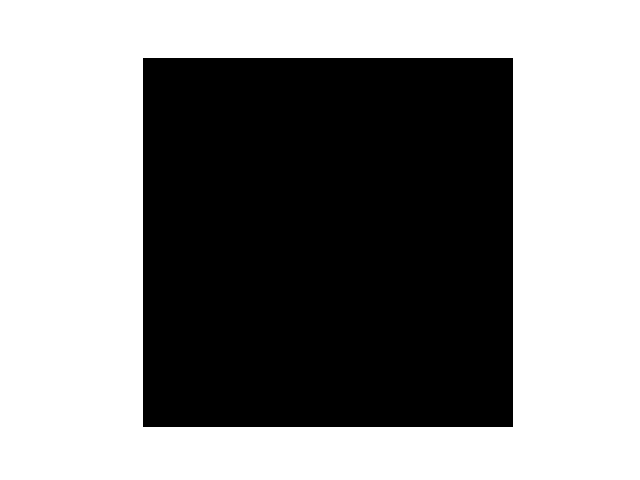

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = np.zeros((512, 512, 3), np.uint8)

fig, ax = plt.subplots()

image_display = ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax.axis("off")


def draw_circle(event):
    if event.button == 1 and event.xdata is not None and event.ydata is not None:
        x = int(event.xdata)
        y = int(event.ydata)

        cv2.circle(img, (x, y), 20, (150, 0, 200), -1)

        image_display.set_data(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        )

        fig.canvas.draw_idle()


fig.canvas.mpl_connect("button_press_event", draw_circle)

plt.show()

<div style="direction:rtl;text-align:right;font-family:Tahoma">
برنامه ای نظیر قلم در paint</div>

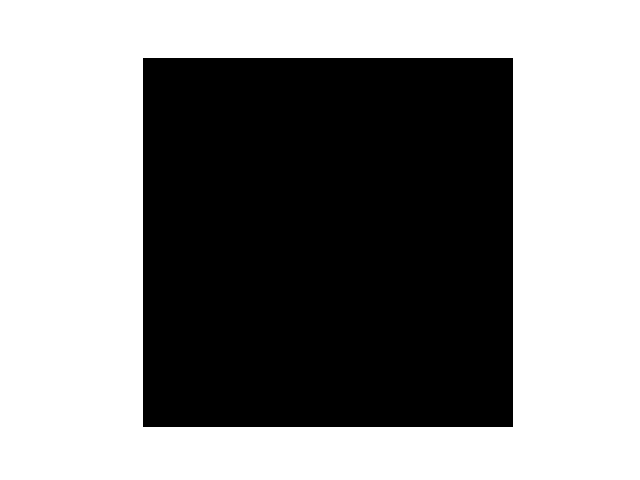

In [4]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import cv2

drawing = False  # true if mouse is pressed

# mouse callback function
def brush(event):
    global drawing

    # Left mouse button pressed
    if event.name == 'button_press_event':
        if event.button == 1:
            drawing = True

    # Mouse movement
    elif event.name == 'motion_notify_event':
        if drawing:
            if event.xdata is not None and event.ydata is not None:
                x = int(event.xdata)
                y = int(event.ydata)

                cv2.circle(img, (x, y), 5, (0, 0, 255), -1)

                image_display.set_data(
                    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                )

                fig.canvas.draw_idle()

    # Left mouse button released
    elif event.name == 'button_release_event':
        if event.button == 1:
            drawing = False


img = np.zeros((512, 512, 3), np.uint8)

fig, ax = plt.subplots()

image_display = ax.imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

ax.axis('off')

# Connect mouse events
fig.canvas.mpl_connect('button_press_event', brush)
fig.canvas.mpl_connect('motion_notify_event', brush)
fig.canvas.mpl_connect('button_release_event', brush)

plt.show()

<div style="direction:rtl;text-align:right;font-family:Tahoma">
تعویض رنگ قلم با رویدادهای کیبورد(r و g و b)</div>

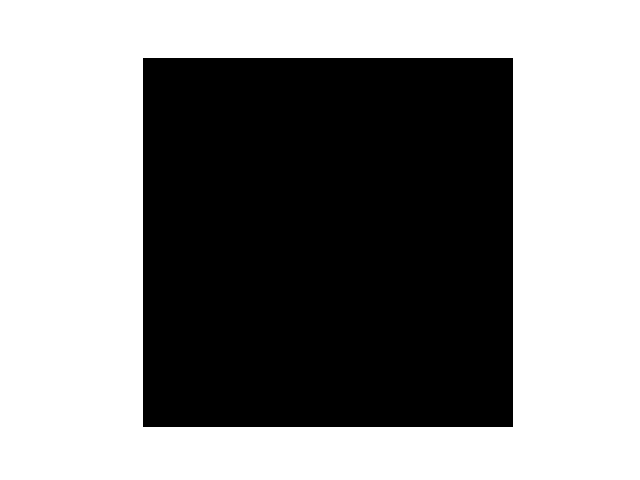

In [5]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import cv2
import ipywidgets as widgets
from IPython.display import display

drawing = False
color = (0, 255, 0)  # green


# Mouse callback function
def brush(event):
    global drawing, color

    # Left mouse button pressed
    if event.name == 'button_press_event':
        if event.button == 1:
            drawing = True

    # Mouse movement
    elif event.name == 'motion_notify_event':
        if drawing:
            if event.xdata is not None and event.ydata is not None:
                x = int(event.xdata)
                y = int(event.ydata)

                cv2.circle(img, (x, y), 5, color, -1)

                image_display.set_data(
                    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                )
                fig.canvas.draw_idle()

    # Left mouse button released
    elif event.name == 'button_release_event':
        if event.button == 1:
            drawing = False


# Change color
def change_color(new_color):
    global color
    color = new_color


# Keyboard
def keyboard(event):
    if event.key == 'b':
        change_color((255, 0, 0))
    elif event.key == 'g':
        change_color((0, 255, 0))
    elif event.key == 'r':
        change_color((0, 0, 255))


img = np.zeros((512, 512, 3), np.uint8)

fig, ax = plt.subplots()

image_display = ax.imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

ax.axis('off')

# Mouse events
fig.canvas.mpl_connect('button_press_event', brush)
fig.canvas.mpl_connect('motion_notify_event', brush)
fig.canvas.mpl_connect('button_release_event', brush)

# Keyboard events
fig.canvas.mpl_connect('key_press_event', keyboard)


# Color buttons
blue_button = widgets.Button(description='Blue (B)')
green_button = widgets.Button(description='Green (G)')
red_button = widgets.Button(description='Red (R)')

blue_button.on_click(lambda x: change_color((255, 0, 0)))
green_button.on_click(lambda x: change_color((0, 255, 0)))
red_button.on_click(lambda x: change_color((0, 0, 255)))

display(widgets.HBox([
    blue_button,
    green_button,
    red_button
]))

plt.show()

<div style="direction:rtl;text-align:right;font-family:Tahoma">
رفع مشکل فاصله بین نقاط</div>

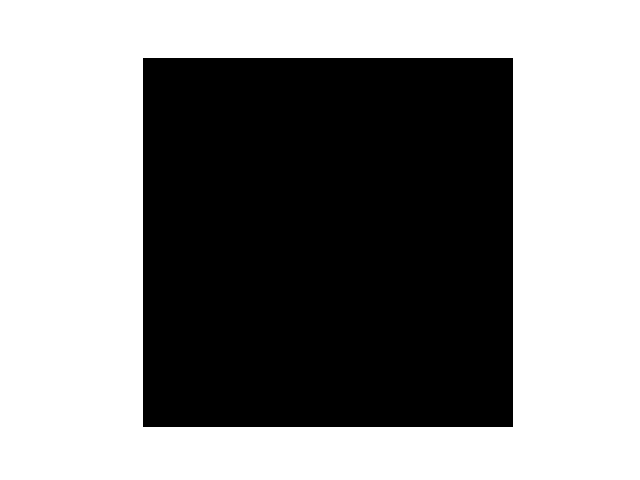

In [6]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import cv2

# Making The Blank Image
img = np.zeros((512, 512, 3), dtype=np.uint8)

drawing = False
ix = 0
iy = 0


# Adding Function Attached To Mouse Callback
def draw(event):
    global ix, iy, drawing

    # Left Mouse Button Down Pressed
    if event.name == 'button_press_event':
        if event.button == 1:
            drawing = True
            ix = int(event.xdata)
            iy = int(event.ydata)

    # Mouse Moving
    elif event.name == 'motion_notify_event':
        if drawing:
            if event.xdata is not None and event.ydata is not None:
                x = int(event.xdata)
                y = int(event.ydata)

                # For Drawing Line
                cv2.line(
                    img,
                    pt1=(ix, iy),
                    pt2=(x, y),
                    color=(255, 255, 255),
                    thickness=3
                )

                ix = x
                iy = y

                image_display.set_data(
                    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                )

                fig.canvas.draw_idle()

    # Left Mouse Button Up
    elif event.name == 'button_release_event':
        if event.button == 1:
            drawing = False


# Making Figure For The Image
fig, ax = plt.subplots()

image_display = ax.imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

ax.axis('off')


# Adding Mouse Events
fig.canvas.mpl_connect('button_press_event', draw)
fig.canvas.mpl_connect('motion_notify_event', draw)
fig.canvas.mpl_connect('button_release_event', draw)


plt.show()

<div style="direction:rtl;text-align:right;font-family:Tahoma">
ترسیم مستطیل تو پر با ماوس</div>

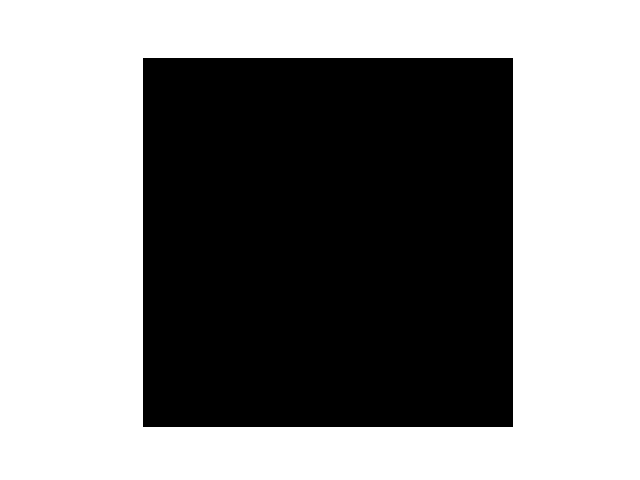

In [7]:
%matplotlib widget

import numpy as np
import cv2
import matplotlib.pyplot as plt

drawing = False
start_point = (0, 0)

def draw_rectangle(event):
    global start_point, drawing

    if event.name == 'button_press_event' and event.button == 1:
        drawing = True
        start_point = (int(event.xdata), int(event.ydata))

    elif event.name == 'motion_notify_event' and drawing:
        if event.xdata is not None and event.ydata is not None:
            x, y = int(event.xdata), int(event.ydata)
            cv2.rectangle(img, start_point, (x, y), (0,255,0), -1)
            image_display.set_data(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            fig.canvas.draw_idle()

    elif event.name == 'button_release_event' and event.button == 1:
        drawing = False

img = np.zeros((512,512,3), np.uint8)

fig, ax = plt.subplots()
image_display = ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax.axis('off')

fig.canvas.mpl_connect('button_press_event', draw_rectangle)
fig.canvas.mpl_connect('motion_notify_event', draw_rectangle)
fig.canvas.mpl_connect('button_release_event', draw_rectangle)

plt.show()

<div style="direction:rtl;text-align:right;font-family:Tahoma">
ترسیم مستطیل تو خالی با ماوس + قابلیت reset صفحه و چاپ مختصات های رسم شده</div>

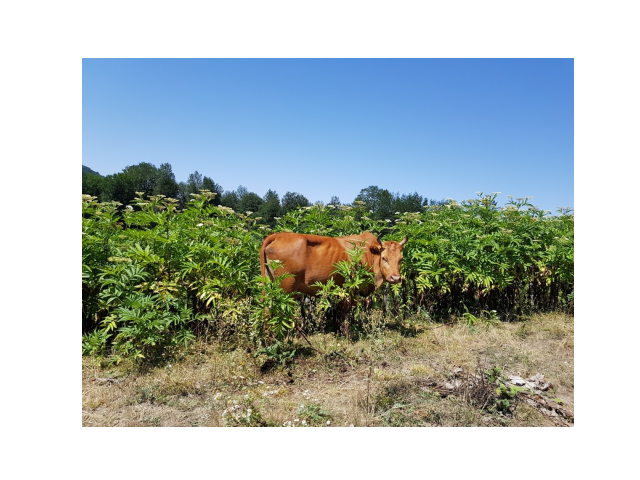

[]


In [12]:
%matplotlib widget

import cv2
import matplotlib.pyplot as plt

start_point = (0, 0)
points = []

image = cv2.imread('../images/input.jpg')
clone = image.copy()

fig, ax = plt.subplots()
display_image = ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax.axis('off')

def draw_empty_rectangle(event):
    global start_point, points, image

    if event.name == 'button_press_event' and event.button == 1:
        start_point = (int(event.xdata), int(event.ydata))

    elif event.name == 'button_release_event' and event.button == 1:
        x, y = int(event.xdata), int(event.ydata)
        points.append([start_point, (x, y)])
        cv2.rectangle(image, start_point, (x, y), (0, 255, 0), 2)
        display_image.set_data(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', draw_empty_rectangle)
fig.canvas.mpl_connect('button_release_event', draw_empty_rectangle)

plt.show()

print(points)

<div style="direction:rtl;text-align:right;font-family:Tahoma">
حل مشکل عدم نمایش مستطیل تا برداشتن کلیک چپ
</div>

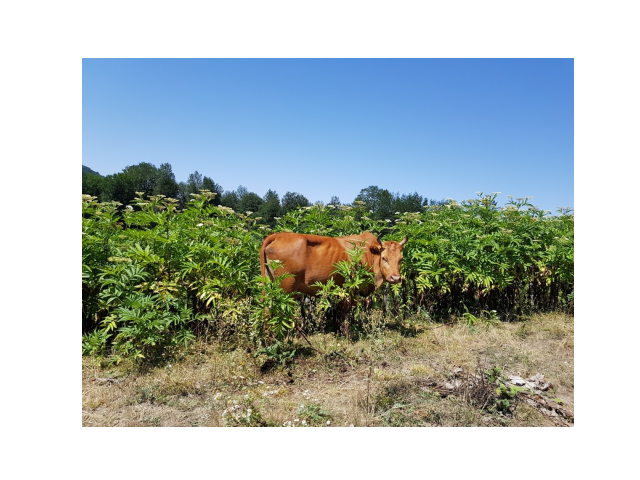

[]


In [17]:
%matplotlib widget

import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets

start_point = (0, 0)
points = []
drawing = False

image = cv2.imread('../images/input.jpg')
clone = image.copy()

fig, ax = plt.subplots()
display_image = ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax.axis('off')

def annotate_image(event):
    global start_point, points, drawing

    if event.name == 'button_press_event' and event.button == 1:
        start_point = (int(event.xdata), int(event.ydata))
        drawing = True

    elif event.name == 'motion_notify_event' and drawing:
        temp_image = image.copy()
        x, y = int(event.xdata), int(event.ydata)
        cv2.rectangle(temp_image, start_point, (x, y), (120, 255, 0), 2)
        display_image.set_data(cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB))
        fig.canvas.draw_idle()

    elif event.name == 'button_release_event' and event.button == 1:
        x, y = int(event.xdata), int(event.ydata)
        points.append([start_point, (x, y)])
        cv2.rectangle(image, start_point, (x, y), (0, 255, 0), 3)
        display_image.set_data(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        drawing = False
        fig.canvas.draw_idle()

def reset(b):
    global image, points
    image = clone.copy()
    points = []
    display_image.set_data(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    fig.canvas.draw_idle()

def exit(b):
    plt.close(fig)

fig.canvas.mpl_connect('button_press_event', annotate_image)
fig.canvas.mpl_connect('motion_notify_event', annotate_image)
fig.canvas.mpl_connect('button_release_event', annotate_image)

reset_button = widgets.Button(description='Reset')
exit_button = widgets.Button(description='Exit')

reset_button.on_click(reset)
exit_button.on_click(exit)

display(widgets.HBox([reset_button, exit_button]))
plt.show()

print(points)

<div style="direction:rtl;text-align:right;font-family:Tahoma">
افزودن قابلیت undo</div>

Output()

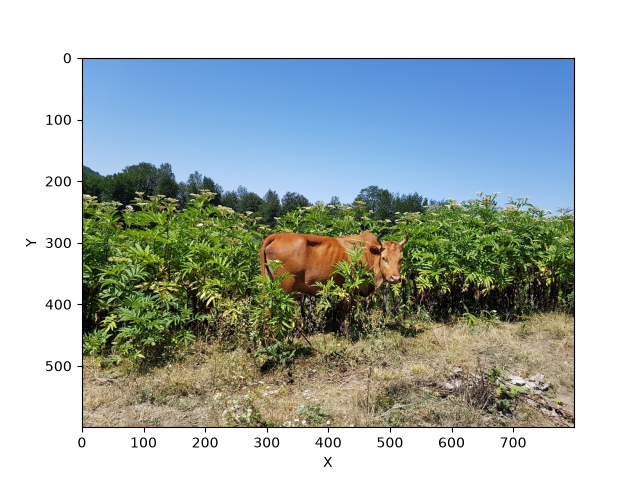

In [19]:
%matplotlib widget

import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets

start_point = (0, 0)
points = []
drawing = False

image = cv2.imread('../images/input.jpg')
clone = image.copy()

fig, ax = plt.subplots()
display_image = ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax.set_xlabel('X')
ax.set_ylabel('Y')

output = widgets.Output()

def show_points():
    with output:
        output.clear_output()
        for i, p in enumerate(points, 1):
            print(f'Rectangle {i}:  Start {p[0]}  →  End {p[1]}')

def annotate_image(event):
    global start_point, points, drawing

    if event.name == 'button_press_event' and event.button == 1:
        start_point = (int(event.xdata), int(event.ydata))
        drawing = True

    elif event.name == 'motion_notify_event' and drawing:
        temp_image = image.copy()
        x, y = int(event.xdata), int(event.ydata)
        cv2.rectangle(temp_image, start_point, (x, y), (120, 255, 0), 2)
        display_image.set_data(cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB))
        fig.canvas.draw_idle()

    elif event.name == 'button_release_event' and event.button == 1:
        x, y = int(event.xdata), int(event.ydata)
        points.append([start_point, (x, y)])
        cv2.rectangle(image, start_point, (x, y), (0, 255, 0), 3)
        display_image.set_data(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        drawing = False
        fig.canvas.draw_idle()
        show_points()

def reset(b):
    global image, points
    image = clone.copy()
    points = []
    display_image.set_data(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    fig.canvas.draw_idle()
    show_points()

def undo(b):
    global image
    if points:
        points.pop()
        image = clone.copy()
        for p in points:
            cv2.rectangle(image, p[0], p[1], (0, 255, 0), 3)
        display_image.set_data(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        fig.canvas.draw_idle()
        show_points()

def exit(b):
    plt.close(fig)

fig.canvas.mpl_connect('button_press_event', annotate_image)
fig.canvas.mpl_connect('motion_notify_event', annotate_image)
fig.canvas.mpl_connect('button_release_event', annotate_image)

reset_button = widgets.Button(description='Reset')
undo_button = widgets.Button(description='Undo')
exit_button = widgets.Button(description='Exit')

reset_button.on_click(reset)
undo_button.on_click(undo)
exit_button.on_click(exit)

display(widgets.HBox([reset_button, undo_button, exit_button]))
display(output)

plt.show()

Related tutorial on OpenCV.org: https://docs.opencv.org/4.6.0/db/d5b/tutorial_py_mouse_handling.html

# 